In [1]:
import os
os.chdir("D:/文章返修/source data/Figure_2/Panel_E")
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import fcluster
import pandas as pd

In [2]:
def classify_rna_data(input_rna, dis, freq, binsize, discard):
    data = input_rna.copy()
    distance = data['E'] - data['S']
    rna_long = data[distance >= dis]
    rna_long_hf = rna_long[rna_long['value'] > freq]
    
    mask_c = (rna_long_hf['S'] <= discard[0]) & (rna_long_hf['value']>discard[1])
    
    hist_data = []
    s = 0
    e = binsize
    lens = data['E'].max()
    while True:
        distance_hf = rna_long_hf[~mask_c]['E'] - rna_long_hf[~mask_c]['S']
        mask = (distance_hf >= s) & (distance_hf <= e)
        hist_data.append(rna_long_hf[~mask_c]['value'][mask].sum())
        s = e
        e += binsize
        if e >= lens:
            break
    
    return rna_long_hf[mask_c], rna_long_hf[~mask_c], hist_data

In [14]:
file_dir = 'D:/文章返修/source data/Figure_2/Panel_E/raw matrix/'
file_list = os.listdir(file_dir)
counts_array = np.zeros(len(file_list), dtype=[('Name','U14'),('C','<f8'),('NC','<f8')])
nc_classify = np.zeros(len(file_list), dtype=[('Name','U14'),('short','<f8'),('mid','<f8'),('long','<f8')])
for i,file_name in enumerate(file_list):
    recom_data = np.loadtxt(file_dir +  file_name, usecols=[0,1,2], dtype=[('S','<f8'),('E','<f8'),('value','<f8')])
    min_value = min(2000, recom_data['value'].max() / 100)
    rna_c, rna_nc, hist_data = classify_rna_data(recom_data, 100, 10, 100, [100, min_value])
    total_c = rna_c['value'].sum()
    total_nc = rna_nc['value'].sum()
    total = total_c + total_nc
    counts_array[i][0] = file_name.split('_')[2] #.split('-')[0]
    counts_array[i][1] = total_c / total
    counts_array[i][2] = total_nc / total
    nc_classify[i][0] = counts_array[i][0]
    nc_classify[i][1] = sum(hist_data[0:50]) / total_nc
    nc_classify[i][2] = sum(hist_data[50:200]) / total_nc
    nc_classify[i][3] = sum(hist_data[200:]) / total_nc

In [15]:
alpha_short = nc_classify['short'][:21]
alpha_mid = nc_classify['mid'][:21]
alpha_long = nc_classify['long'][:21]

beta_short = nc_classify['short'][21:94]
beta_mid = nc_classify['mid'][21:94]
beta_long = nc_classify['long'][21:94]

gama_short = nc_classify['short'][94:99]
gama_mid = nc_classify['mid'][94:99]
gama_long = nc_classify['long'][94:99]

delta_short = nc_classify['short'][99:103]
delta_mid = nc_classify['mid'][99:103]
delta_long = nc_classify['long'][99:103]

datas = [alpha_short, alpha_mid, alpha_long,
         beta_short, beta_mid, beta_long,
         gama_short, gama_mid, gama_long,
         delta_short, delta_mid, delta_long]

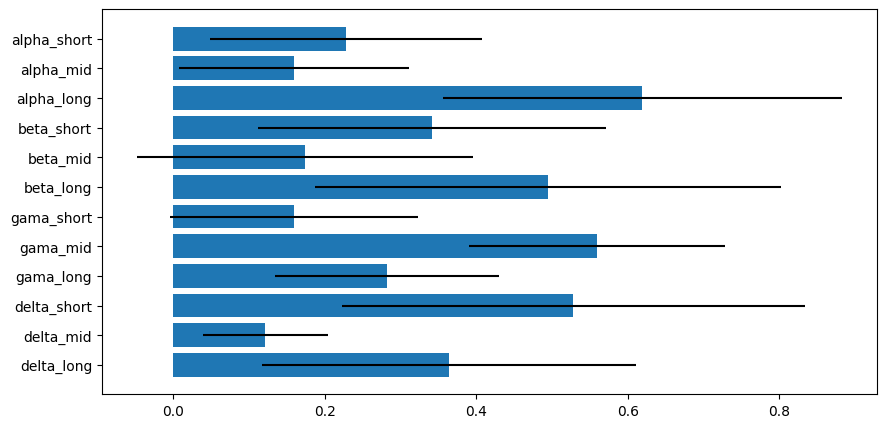

In [ ]:
means = [np.mean(i) for i in datas]
stds = [np.std(i, ddof=1) for i in datas]
labels = ('alpha_short', 'alpha_mid', 'alpha_long',
          'beta_short', 'beta_mid', 'beta_long',
          'gama_short', 'gama_mid', 'gama_long',
          'delta_short', 'delta_mid', 'delta_long')

fig, ax = plt.subplots(figsize=(10,5))


ax.barh(labels, means, xerr=stds, align='center')
ax.invert_yaxis()

plt.show()

In [20]:
df = pd.DataFrame({
    'short': nc_classify['short'][99:103],
    'mid':   nc_classify['mid'][99:103],
    'long':  nc_classify['long'][99:103]
})
df.to_excel('delta.xlsx', index=False)